In [26]:
import pandas as pd
import numpy as np
df = pd.read_csv('diabetes_dataset.csv')

df["class"] = df["class"].map({"Positive": 1, "Negative": 0})

dataFrameCommon = df.drop(["Age", "Gender", "class"], axis=1)
featuresCommon = dataFrameCommon.columns

for x in featuresCommon:
    df[x] = df[x].map({'Yes':1, 'No':0})

df["Gender"] = df["Gender"].map({'Male':1,'Female':0})

#Splitting data - modify test size at your leasure, just tell everyone you did it
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.2,random_state=42)


## Oversampling cuz it sounds better
positive = train[train["class"] == 0]
negative = train[train["class"] == 1]

positive_overs = positive.sample(
    n=len(negative),
    replace=True,
    random_state=42
)

train_balanced = pd.concat([negative, positive_overs])


# For future use for modelz and shitz
x_train = train_balanced.drop(columns=["class"])
y_train = train_balanced[["class"]]
x_test = test.drop(columns=['class'])
y_test = test[['class']]
#print(x_train.head(),y_train.head())
#test.head()
#Checks
#datasetValues=df["class"].value_counts()
#print(f"Amount of Postive Values in a dataset {datasetValues}")
#trainValues=train["class"].value_counts()
#print(f"Amount of Postive Values in a training dataset {trainValues}")
#testValues=test["class"].value_counts()
#print(f"Amount of Postive Values in a test dataset {testValues}")
#datasetValuesBalanced=train_balanced["class"].value_counts()
#print(f"Amount of Positive Values in a balanced training dataset {datasetValuesBalanced}")

## Tree creation

[0 1]


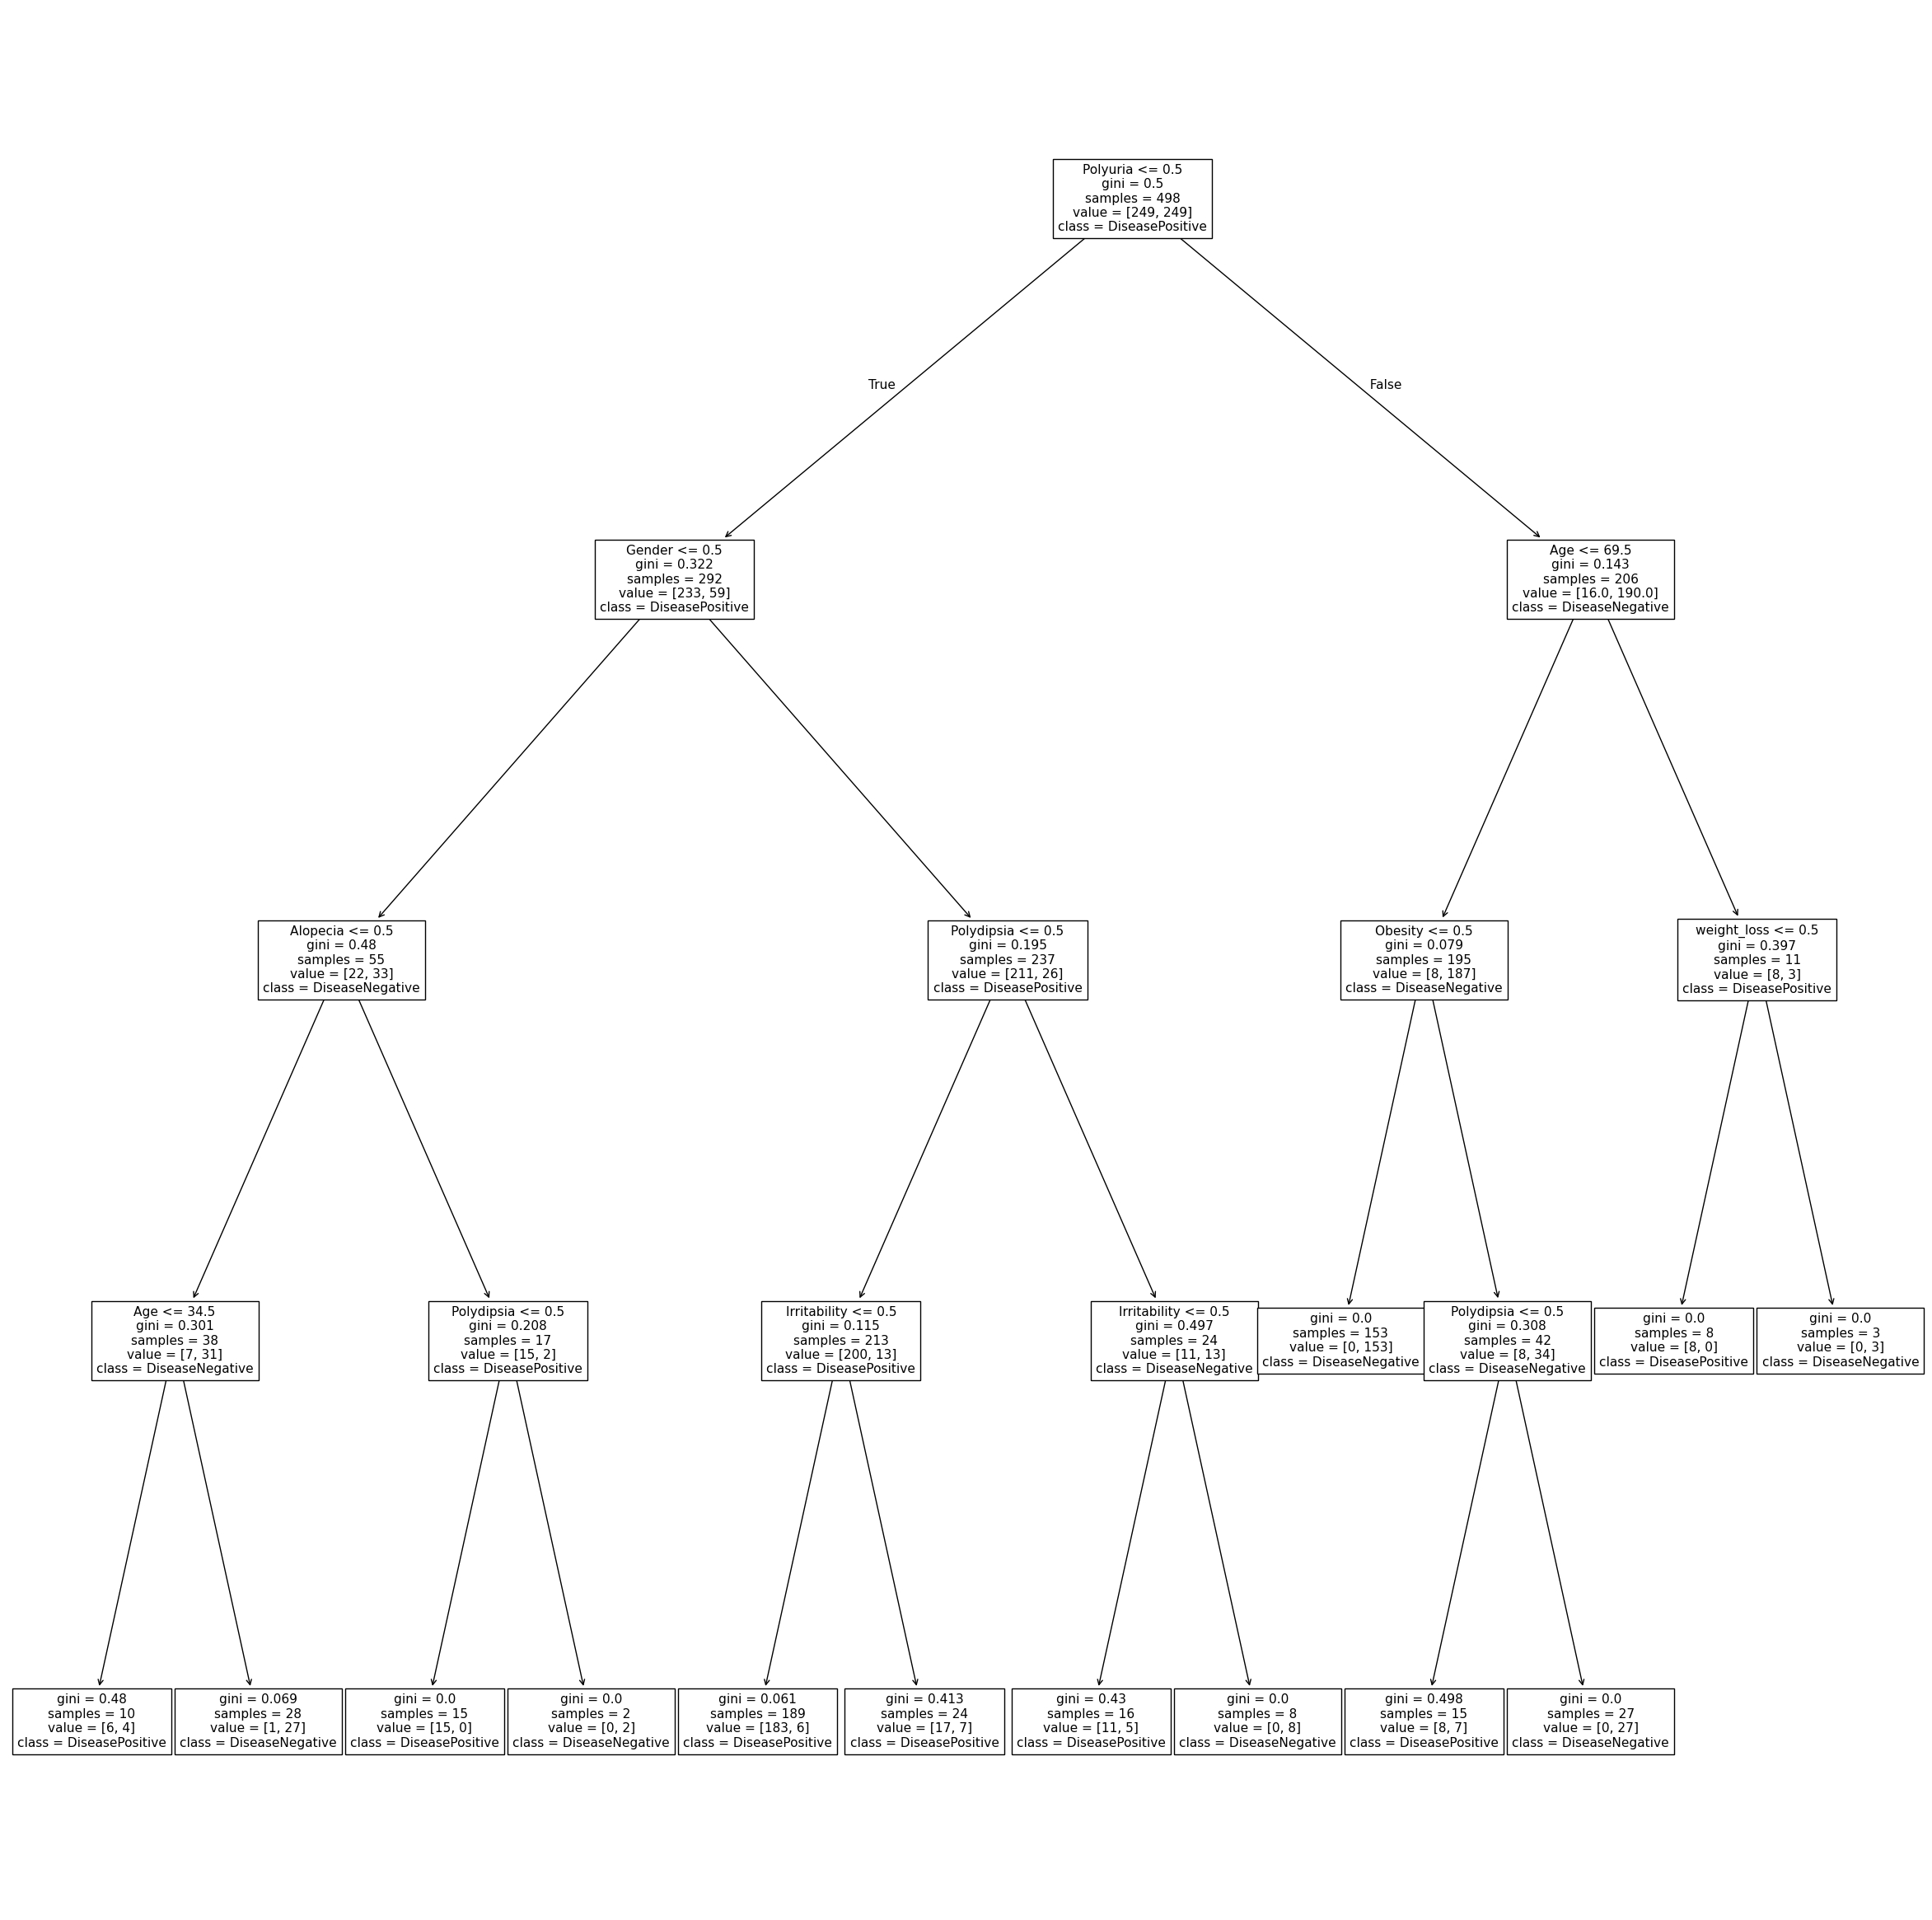

In [38]:

from sklearn.tree import DecisionTreeClassifier
decisionTreeClasiffier = DecisionTreeClassifier(random_state=42, max_depth=4)
decisionTreeClasiffier.fit(x_train,y_train)

pred = decisionTreeClasiffier.predict(x_test)
#print(pred)

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import matplotlib
plt.figure(figsize=(30,30))

print(decisionTreeClasiffier.classes_)
dtcClasses=["DiseasePositive","DiseaseNegative"]
x=plot_tree(decisionTreeClasiffier, feature_names=decisionTreeClasiffier.feature_names_in_, class_names=dtcClasses)

## ClassifierEvaluation

In [39]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, pred) ## Computest accuracy score
acc

0.9326923076923077